Class distribution:
 mortality
0    7782
1     218
Name: count, dtype: int64

RQ3 Results:

        Preprocessing  Accuracy  Precision  Recall        F1       AUC
0            Raw Data    0.0275   0.027500     1.0  0.053528  0.564403
1          Imputation    0.0275   0.027500     1.0  0.053528  0.564403
2  Scaling + Encoding    0.0290   0.027541     1.0  0.053606  0.567319
3       Full Pipeline    0.0290   0.027541     1.0  0.053606  0.567319


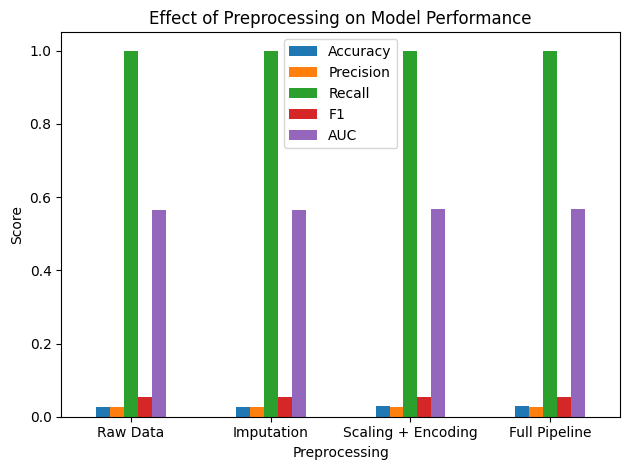

In [7]:
# SETUP

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


# LOAD DATASET

df = pd.read_csv('/kaggle/input/datasets/uom190346a/synthetic-clinical-tabular-dataset/synthetic_clinical_dataset.csv')


# DEFINE X and y

y = df['mortality']
X = df.drop(columns=['mortality'])


# COLUMN TYPES

numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns


# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Class distribution:\n", y_train.value_counts())


# MODEL

def get_model():
    return LogisticRegression(
        max_iter=5000,
        solver='liblinear',
        class_weight='balanced'
    )


# COMMON THRESHOLD (IMPORTANT)

threshold = 0.2


# RQ3: EFFECT OF PREPROCESSING

results = []


# 1. RAW DATA

X_train_num = X_train.select_dtypes(include=['int64','float64'])
X_test_num = X_test.select_dtypes(include=['int64','float64'])

model = get_model()
model.fit(X_train_num, y_train)

y_prob = model.predict_proba(X_test_num)[:, 1]
y_pred = (y_prob > threshold).astype(int)

results.append([
    "Raw Data",
    accuracy_score(y_test, y_pred),
    precision_score(y_test, y_pred, zero_division=0),
    recall_score(y_test, y_pred, zero_division=0),
    f1_score(y_test, y_pred, zero_division=0),
    roc_auc_score(y_test, y_prob)
])


# 2. IMPUTATION ONLY

imputer = SimpleImputer(strategy='mean')

X_train_imp = imputer.fit_transform(X_train_num)
X_test_imp = imputer.transform(X_test_num)

model = get_model()
model.fit(X_train_imp, y_train)

y_prob = model.predict_proba(X_test_imp)[:, 1]
y_pred = (y_prob > threshold).astype(int)

results.append([
    "Imputation",
    accuracy_score(y_test, y_pred),
    precision_score(y_test, y_pred, zero_division=0),
    recall_score(y_test, y_pred, zero_division=0),
    f1_score(y_test, y_pred, zero_division=0),
    roc_auc_score(y_test, y_prob)
])


# 3. SCALING + ENCODING

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

model_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', get_model())
])

model_pipe.fit(X_train, y_train)

y_prob = model_pipe.predict_proba(X_test)[:, 1]
y_pred = (y_prob > threshold).astype(int)

results.append([
    "Scaling + Encoding",
    accuracy_score(y_test, y_pred),
    precision_score(y_test, y_pred, zero_division=0),
    recall_score(y_test, y_pred, zero_division=0),
    f1_score(y_test, y_pred, zero_division=0),
    roc_auc_score(y_test, y_prob)
])


# 4. FULL PIPELINE

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

full_preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

model_full = Pipeline([
    ('preprocessor', full_preprocessor),
    ('model', get_model())
])

model_full.fit(X_train, y_train)

y_prob = model_full.predict_proba(X_test)[:, 1]
y_pred = (y_prob > threshold).astype(int)

results.append([
    "Full Pipeline",
    accuracy_score(y_test, y_pred),
    precision_score(y_test, y_pred, zero_division=0),
    recall_score(y_test, y_pred, zero_division=0),
    f1_score(y_test, y_pred, zero_division=0),
    roc_auc_score(y_test, y_prob)
])


# RESULTS TABLE

results_df = pd.DataFrame(results, columns=[
    'Preprocessing','Accuracy','Precision','Recall','F1','AUC'
])

print("\nRQ3 Results:\n")
print(results_df)


# SAVE RESULTS

results_df.to_csv("rq3_table.csv", index=False)


# BAR CHART

results_df.set_index('Preprocessing')[['Accuracy','Precision','Recall','F1','AUC']].plot(kind='bar')

plt.title("Effect of Preprocessing on Model Performance")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("rq3_bar_chart.pdf")
plt.show()